<a href="https://colab.research.google.com/github/SRIBALAJI00/BDML-LAB/blob/main/predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exp-2 Statistical Analysis of Dataset

Dataset Loaded Successfully
   Hong Kong  Very high  Unnamed: 2  Unnamed: 3  Unnamed: 4  1.6  Unnamed: 6  \
0  Australia  Very high       0.073        19.0         6.0  8.1        37.9   
1    Denmark  Very high       0.013         1.0         4.0  1.9        39.7   
2     Sweden  Very high       0.023         4.0         4.0  3.3        47.0   
3    Ireland  Very high       0.074        21.0         5.0  5.9        27.3   
4    Germany  Very high       0.073        19.0         7.0  7.5        34.8   

   77.1  83.4  53.5  65.8  
0  94.6  94.4  61.1  70.5  
1  95.1  95.2  57.7  66.7  
2  91.8  92.2  61.7  68.0  
3  88.1  86.0  56.5  68.6  
4  96.1  96.5  56.8  66.0  

Mean Values:
Unnamed: 2      0.350102
Unnamed: 3     86.832335
Unnamed: 4    162.618785
1.6            45.471728
Unnamed: 6     24.394737
77.1           62.001156
83.4           66.423121
53.5           50.018182
65.8           69.854545
dtype: float64

Standard Deviation:
Unnamed: 2      0.194116
Unnamed: 3     48.41955

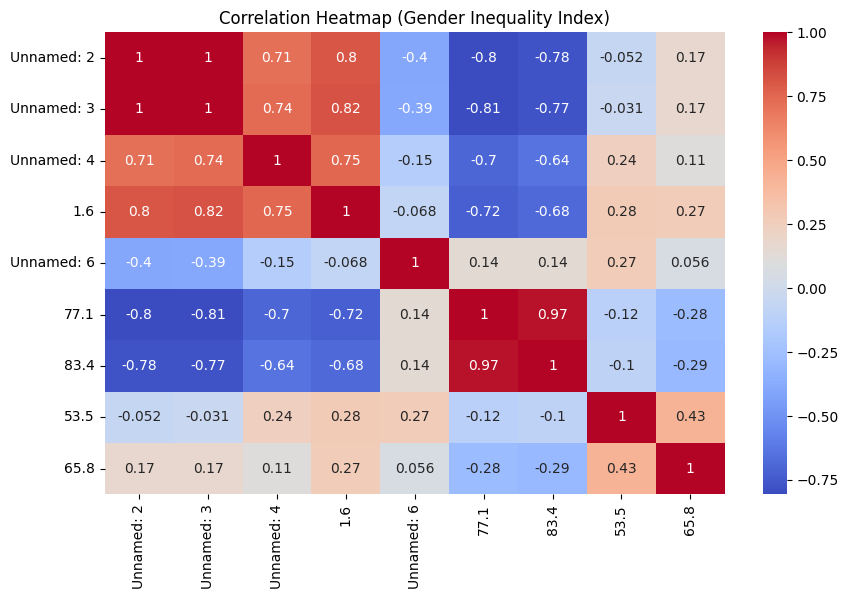

GII column not found. Please check column names.


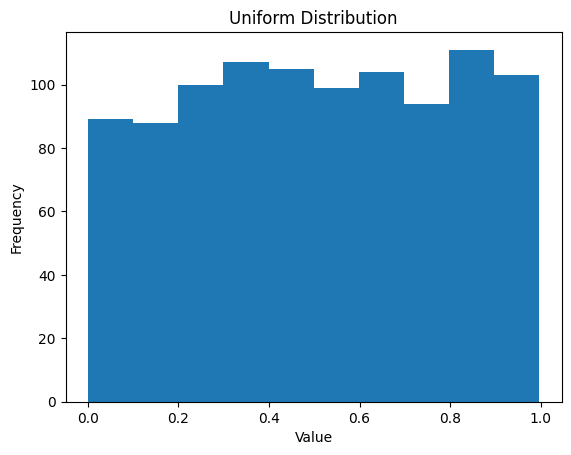

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset, skipping initial metadata rows
df = pd.read_csv("/content/Gender_Inequality_Index.csv", header=4)

print("Dataset Loaded Successfully")
print(df.head())

# Select only numerical columns for statistical analysis
num_df = df.select_dtypes(include=np.number)


print("\nMean Values:")
print(num_df.mean())


print("\nStandard Deviation:")
print(num_df.std())


print("\nVariance:")
print(num_df.var())

print("\nCorrelation Matrix:")
# Drop rows with all NaN values before calculating correlation to avoid all-NaN slices
print(num_df.dropna().corr())

plt.figure(figsize=(10,6))
# Use dropna() for heatmap to handle potential NaNs in correlation matrix
sns.heatmap(num_df.dropna().corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Gender Inequality Index)")
plt.show()


gii_cols = [col for col in df.columns if 'gii' in col.lower() or 'gender inequality index' in col.lower()]

if len(gii_cols) > 0:
    # Assuming the first found GII column is the correct one for plotting
    gii_col = gii_cols[0]
    plt.figure()
    sns.histplot(df[gii_col].dropna(), kde=True)
    plt.title("Normal Distribution of Gender Inequality Index (GII)")
    plt.xlabel("GII Value")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("GII column not found. Please check column names.")


uniform_data = np.random.uniform(0, 1, 1000)

plt.figure()
plt.hist(uniform_data)
plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

EXP-3 Missing Value Analysis and Outlier Analysis

Dataset Loaded Successfully
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Missing Values Count:
age         134
sex         134
bmi         134
children      0
smoker        0
region        0
charges     134
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1204.000000  1204.000000  1338.000000   1204.000000
mean     39.206811    30.632566     1.094918  13056.041441
std      14.080740     6.159517     1.205493  11831.721806
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.195000     0.000000   4687.444925
50%      39.000000    30.250000     1.000000   9285.794350
75%  

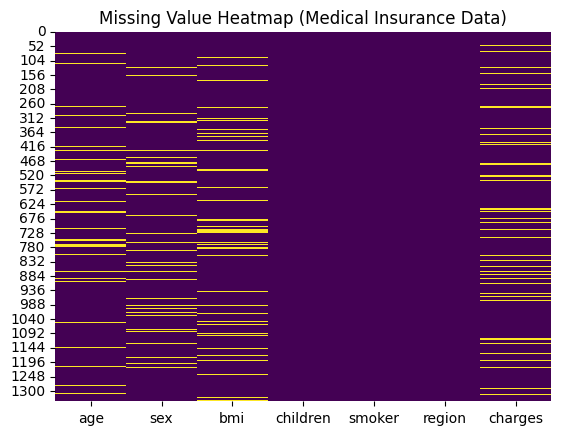


Missing Values After Imputation:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


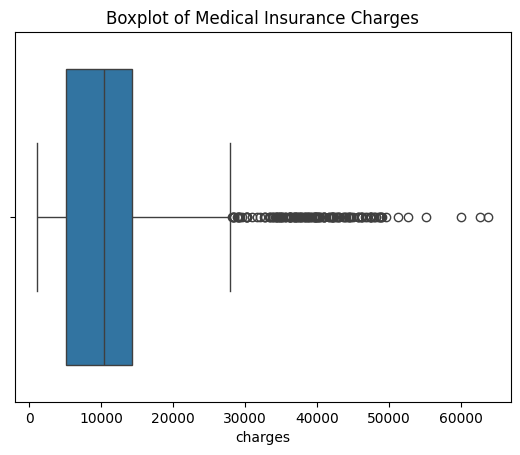

Number of IQR Outliers: 149
Number of Z-Score Outliers: 22
Number of Percentile Outliers: 28


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print(df.head())

np.random.seed(42)

for col in ['age', 'bmi', 'charges']:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

df.loc[df.sample(frac=0.1).index, 'sex'] = np.nan


print("\nMissing Values Count:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (Medical Insurance Data)')
plt.show()


df_impute = df.copy()

df_impute['age'] = df_impute['age'].fillna(df_impute['age'].mean())
df_impute['bmi'] = df_impute['bmi'].fillna(df_impute['bmi'].median())
df_impute['charges'] = df_impute['charges'].fillna(df_impute['charges'].mean())
df_impute['sex'] = df_impute['sex'].fillna(df_impute['sex'].mode()[0])

print("\nMissing Values After Imputation:")
print(df_impute.isnull().sum())

sns.boxplot(x=df_impute['charges'])
plt.title("Boxplot of Medical Insurance Charges")
plt.show()


Q1 = df_impute['charges'].quantile(0.25)
Q3 = df_impute['charges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = df_impute[
    (df_impute['charges'] < lower) | (df_impute['charges'] > upper)
]

print("Number of IQR Outliers:", iqr_outliers.shape[0])

# Ensure zscore is calculated on non-null values for consistency, though fillna already handled this
z_outliers = df_impute[np.abs(zscore(df_impute['charges'])) > 3]
print("Number of Z-Score Outliers:", z_outliers.shape[0])

lower_p = df_impute['charges'].quantile(0.01)
upper_p = df_impute['charges'].quantile(0.99)

percentile_outliers = df_impute[
    (df_impute['charges'] < lower_p) |
    (df_impute['charges'] > upper_p)
]

print("Number of Percentile Outliers:", percentile_outliers.shape[0])

Exp-4 Data Visualization & Multiple Variable Summary

Dataset Loaded Successfully
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450 

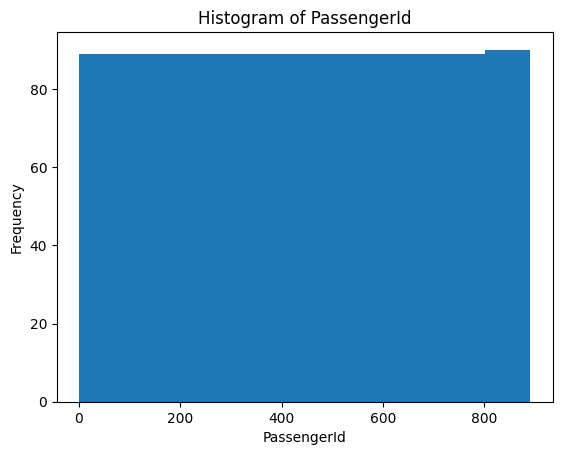

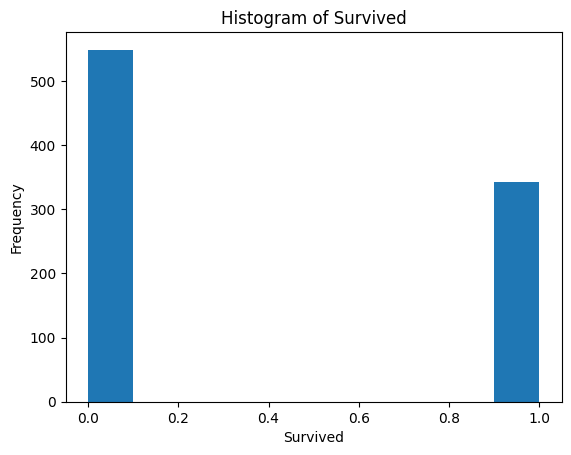

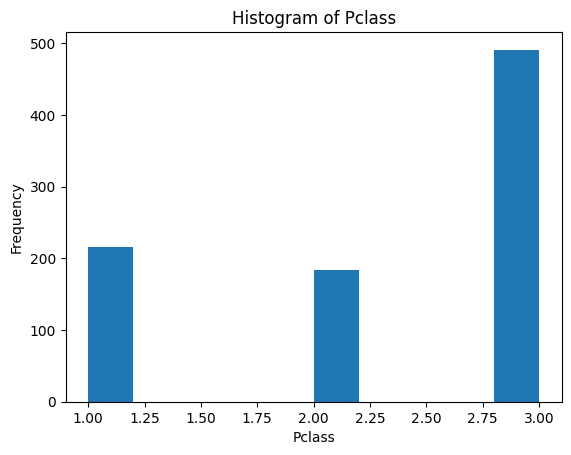

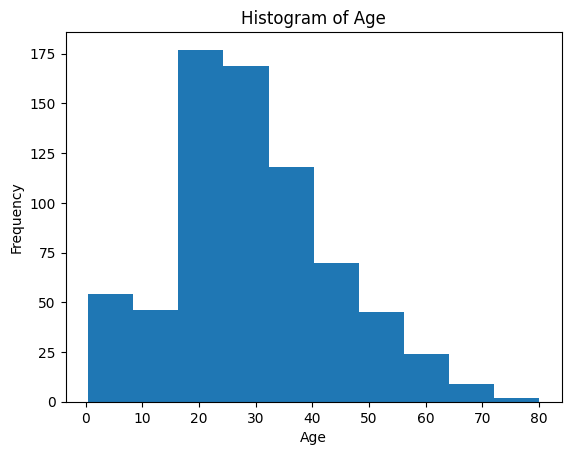

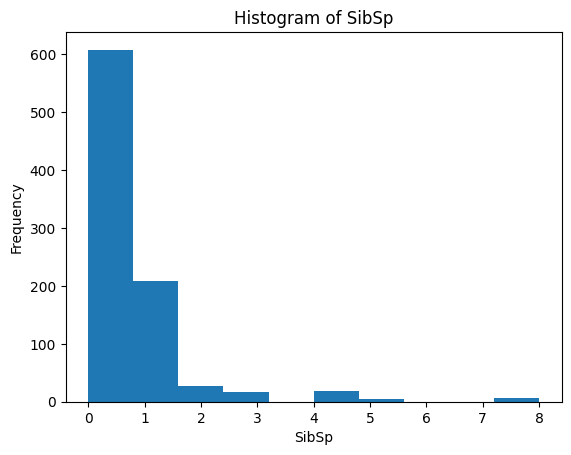

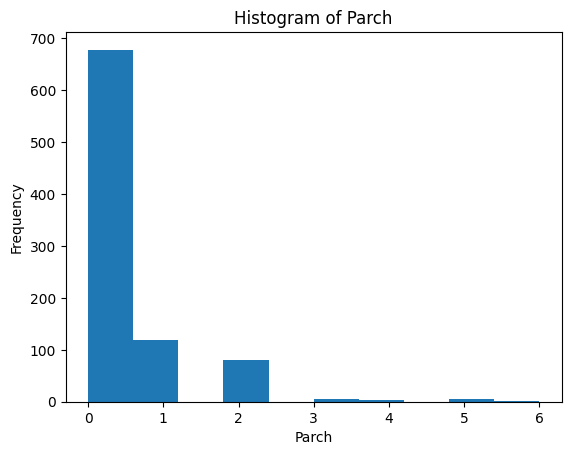

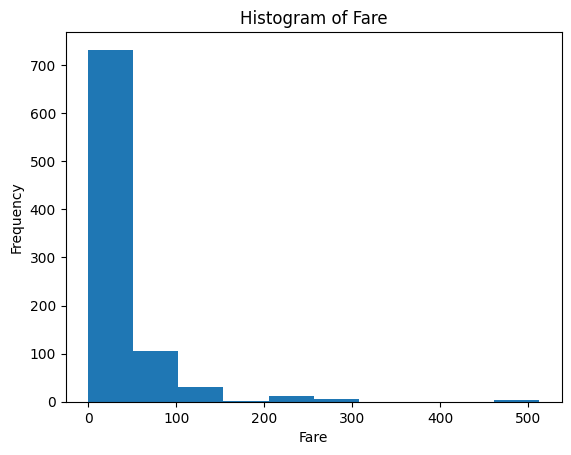

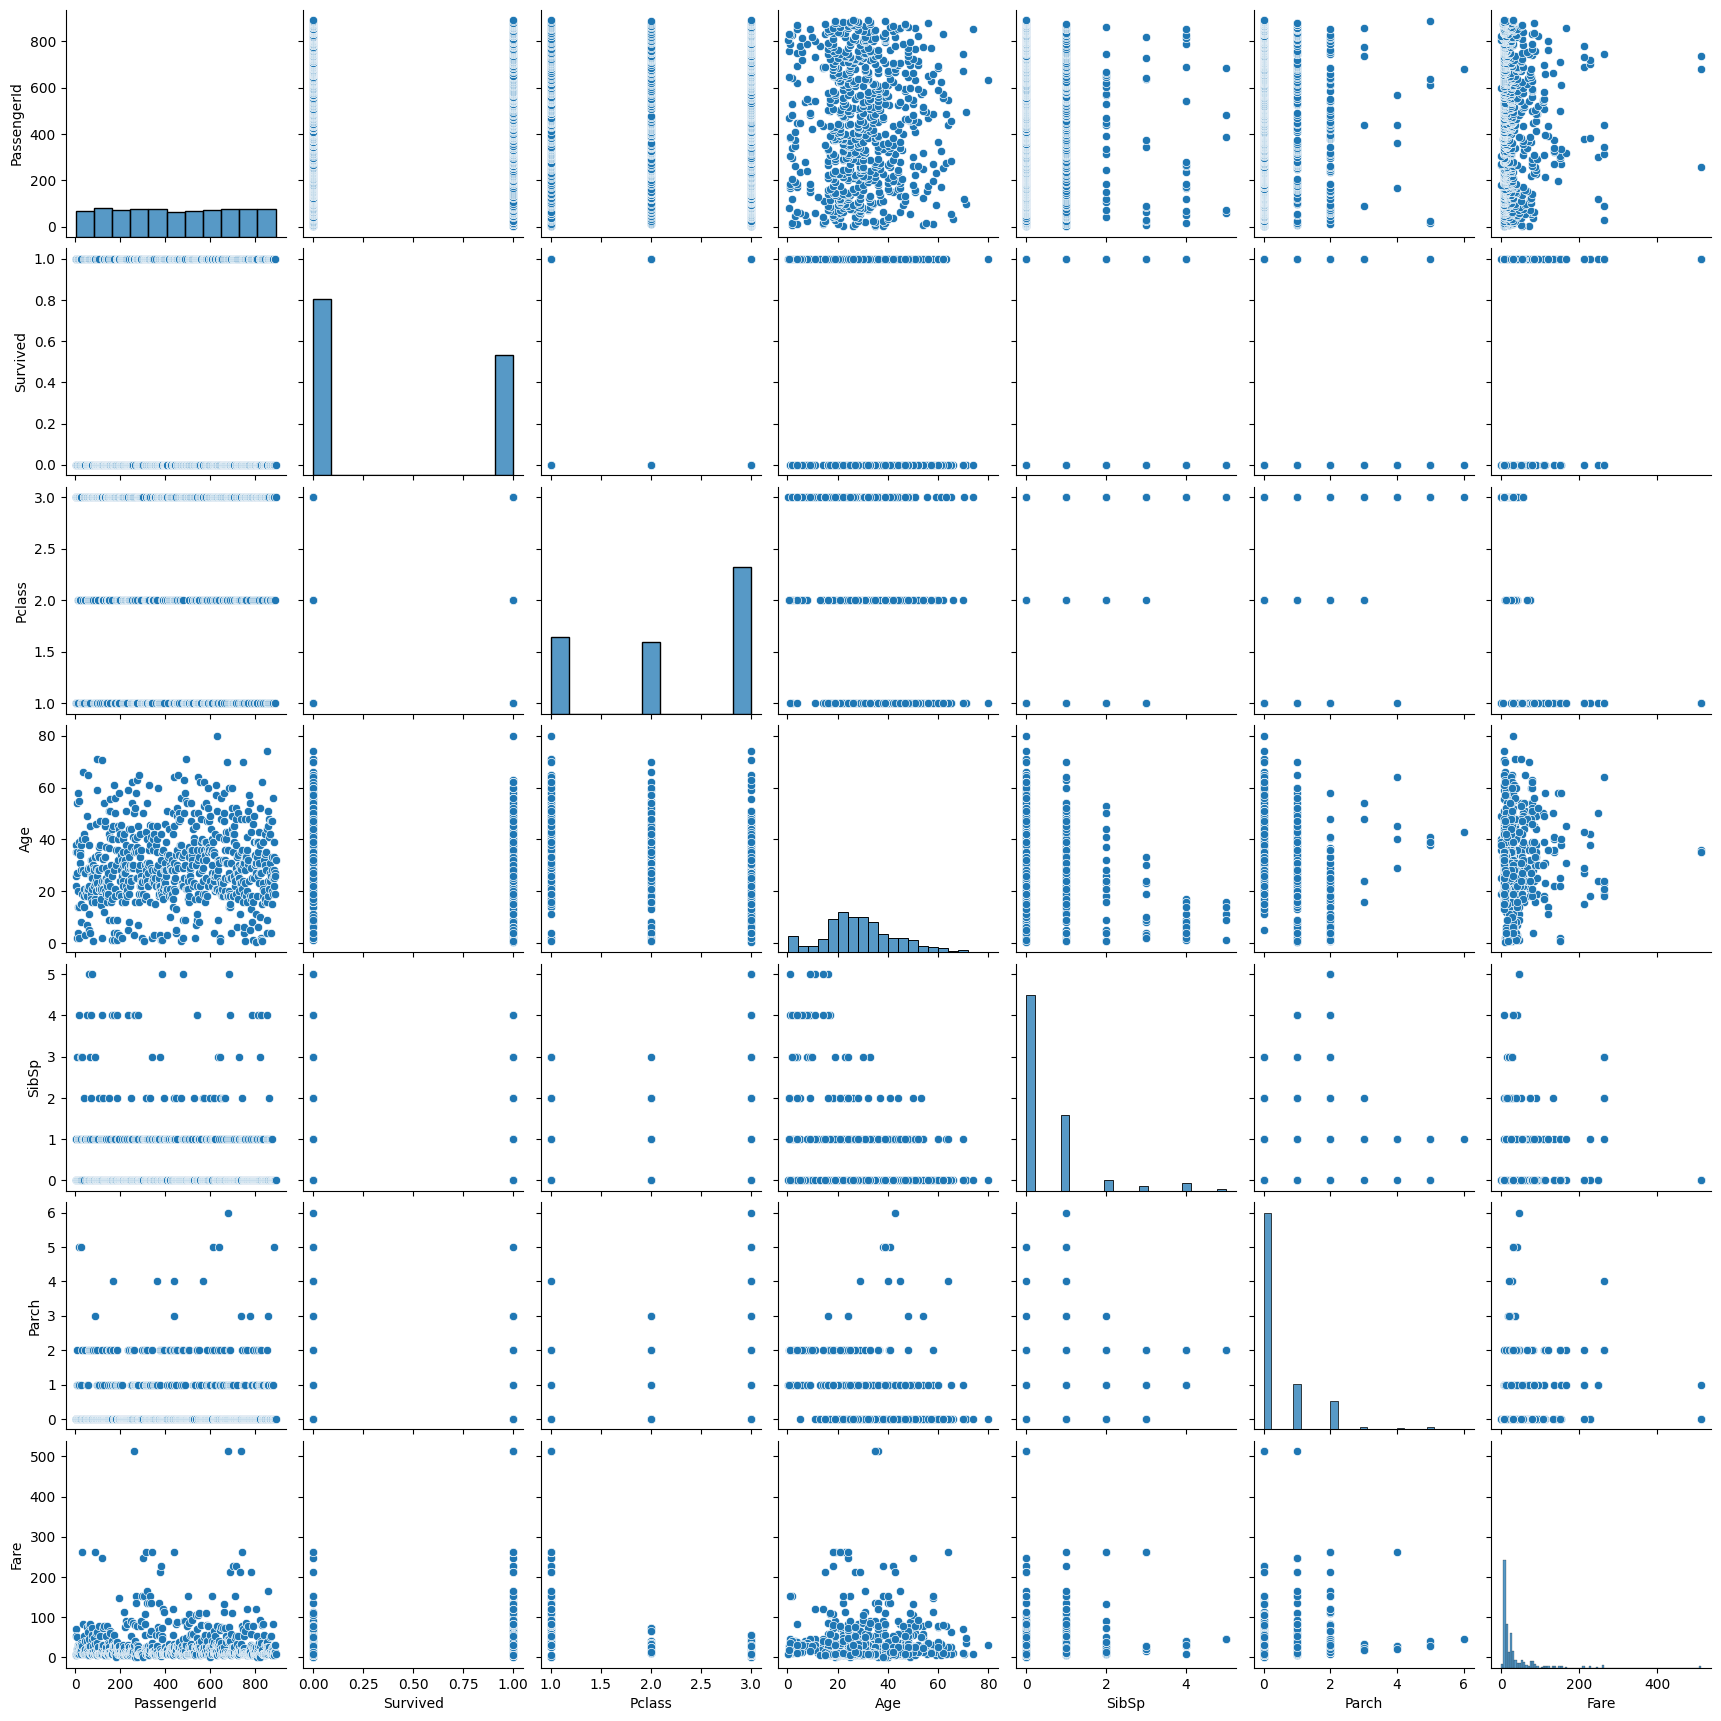

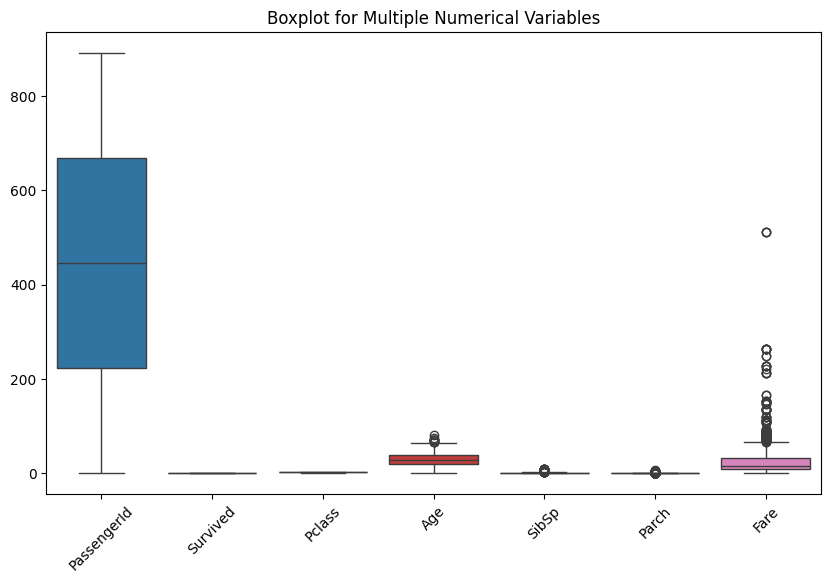

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("titanic.xlsx")

print("Dataset Loaded Successfully")
print(df.head())


print("\nDataset Summary:")
print(df.describe(include='all'))

num_df = df.select_dtypes(include=np.number)


for col in num_df.columns:
    plt.figure()
    plt.hist(num_df[col].dropna())
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


sns.pairplot(num_df.dropna())
plt.show()


plt.figure(figsize=(10,6))
sns.boxplot(data=num_df)
plt.title("Boxplot for Multiple Numerical Variables")
plt.xticks(rotation=45)
plt.show()


Exp 5  DATA VISUALIZATION, TRANSFORMATION, BINNING,SKEW FIXING AND SAMPLING USING TITANIC DATASET

Dataset Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Correlation Matrix:
             PassengerId  Survived    Pclas

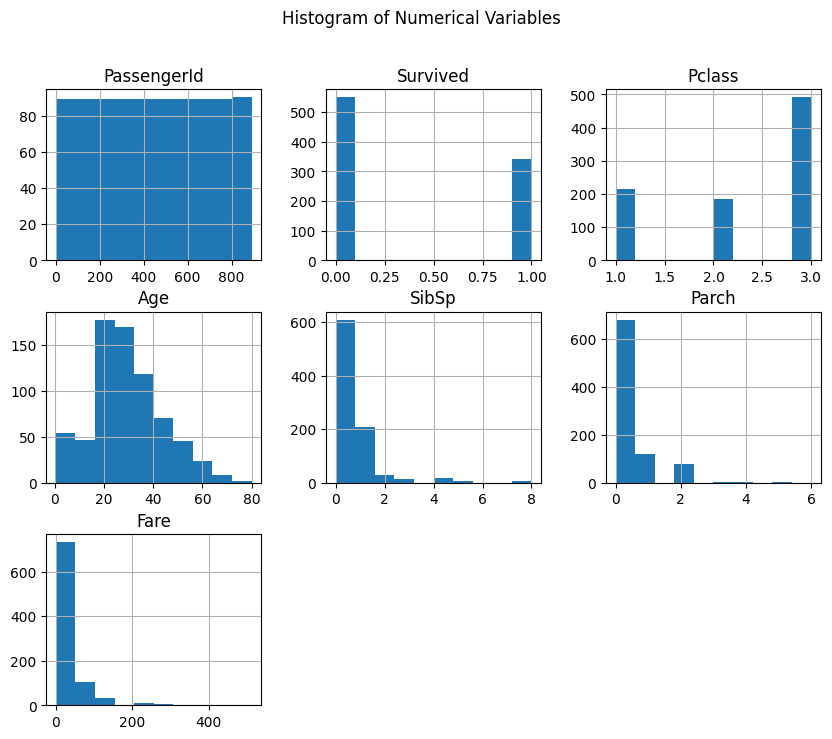

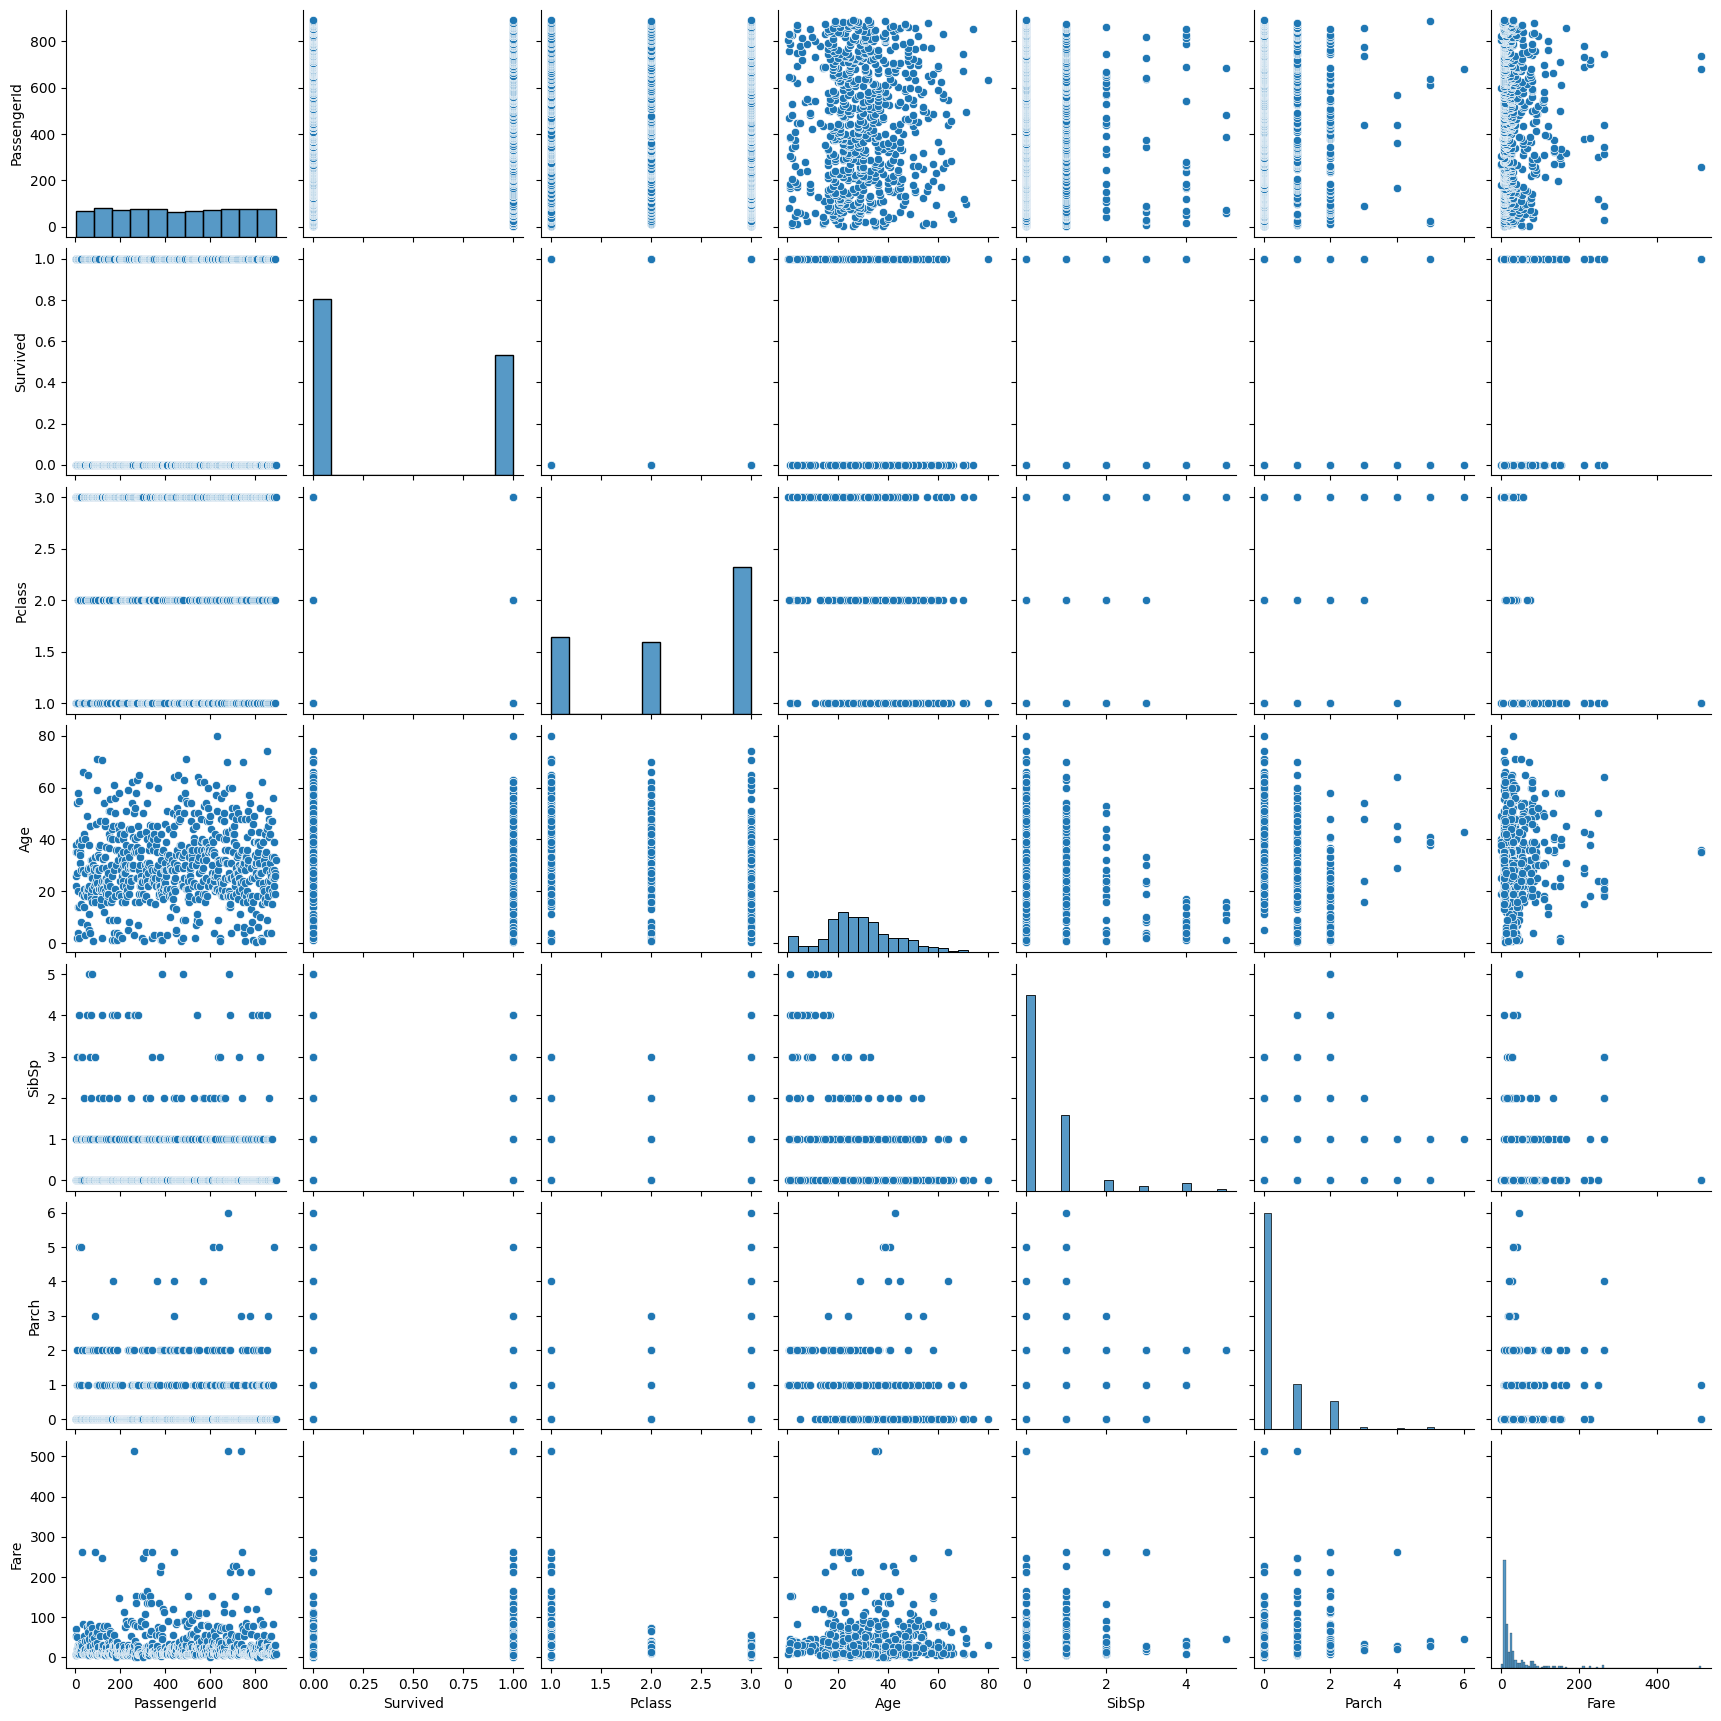


Log Transformation Applied to 'Fare' column

Binning Result for 'Fare' column:
      Fare binned_fare
0   7.2500    Very Low
1  71.2833    Very Low
2   7.9250    Very Low
3  53.1000    Very Low
4   8.0500    Very Low

Skewness Before Fix:
PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

Skewness After Fix (Fare column):
2.08500441820235

Random Sample:
     PassengerId  Survived  Pclass  \
862          863         1       1   
223          224         0       3   
84            85         1       2   
680          681         0       3   
535          536         1       2   
623          624         0       3   
148          149         0       2   
3              4         1       1   
34            35         0       1   
241          242         1       3   

                                                  Name     Sex   Age  SibSp  \
862  Swift,

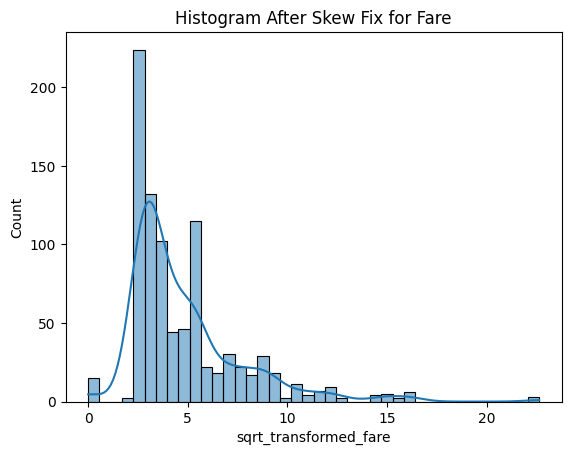

In [ ]:
# ==========================================
# DATA VISUALIZATION, TRANSFORMATION, BINNING,
# SKEW FIXING AND SAMPLING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (example: CSV file)
df = pd.read_csv("data.csv")

# ------------------------------------------
# 1. Multiple Variable Summary
# ------------------------------------------
print("Dataset Summary:")
print(df.describe())

print("\nCorrelation Matrix:")
print(df.corr())

# ------------------------------------------
# 2. Histogram Visualization
# ------------------------------------------
df.hist(figsize=(10,8))
plt.suptitle("Histogram of Numerical Variables")
plt.show()

# ------------------------------------------
# 3. Data Visualization (Scatter + Pairplot)
# ------------------------------------------
sns.pairplot(df)
plt.show()

# ------------------------------------------
# 4. Transformation (Log Transformation)
# ------------------------------------------
# Apply log transform to reduce skew
df['log_transformed'] = np.log1p(df.select_dtypes(include=np.number).iloc[:,0])

print("\nLog Transformation Applied")

# --------------------------------------l----
# 5. Binning
# ------------------------------------------
df['binned'] = pd.cut(df.select_dtypes(include=np.number).iloc[:,0],
                      bins=5,
                      labels=["Very Low","Low","Medium","High","Very High"])

print("\nBinning Result:")
print(df[['binned']].head())

# ------------------------------------------
# 6. Fixing Skew Values
# ------------------------------------------
skew_value = df.select_dtypes(include=np.number).skew()
print("\nSkewness Before Fix:")
print(skew_value)

# Square root transformation
df['sqrt_transformed'] = np.sqrt(df.select_dtypes(include=np.number).iloc[:,0])

print("\nSkewness After Fix:")
print(df['sqrt_transformed'].skew())

# ------------------------------------------
# 7. Sampling
# ------------------------------------------
sample_df = df.sample(n=10, random_state=1)

print("\nRandom Sample:")
print(sample_df)

# ------------------------------------------
# Visualization after transformation
# ------------------------------------------
sns.histplot(df['sqrt_transformed'], kde=True)
plt.title("Histogram After Skew Fix")
plt.show()

exp 1 Clustering Based Data Analytics (K-Means + SOM)

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=517d3aa5bf333640331a9f548438aaac2ea9d6961701c311a885f52ea8a49744
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom
Dataset Sample:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

K-Means Cluster Assignment:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1             

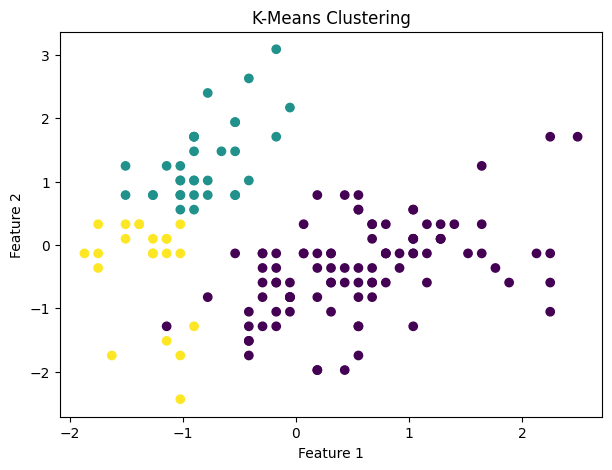


Training SOM...


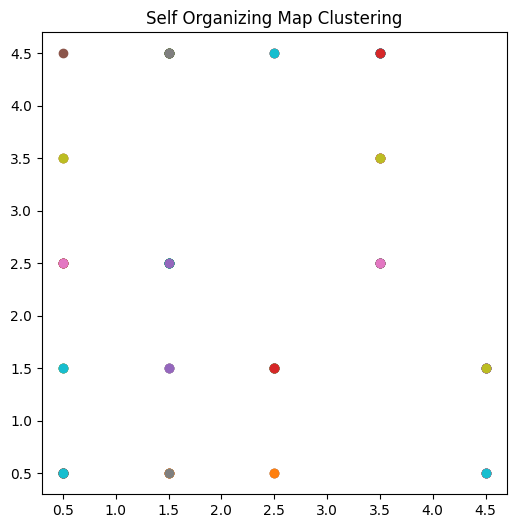

In [ ]:
# ==========================================
# CLUSTERING BASED DATA ANALYTICS
# K-MEANS AND SOM ALGORITHMS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# SOM library
!pip install minisom

from minisom import MiniSom

# ------------------------------------------
# Load Dataset (Iris Dataset)
# ------------------------------------------
data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)

print("Dataset Sample:")
print(df.head())

# ------------------------------------------
# Data Standardization
# ------------------------------------------
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# ------------------------------------------
# K-MEANS CLUSTERING
# ------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

clusters = kmeans.labels_

df['KMeans_Cluster'] = clusters

print("\nK-Means Cluster Assignment:")
print(df.head())

# ------------------------------------------
# Visualize K-Means Clusters
# ------------------------------------------
plt.figure(figsize=(7,5))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=clusters,
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# ------------------------------------------
# SOM (Self Organizing Map)
# ------------------------------------------
som = MiniSom(
    x=5,
    y=5,
    input_len=scaled_data.shape[1],
    sigma=1.0,
    learning_rate=0.5
)

som.random_weights_init(scaled_data)

print("\nTraining SOM...")
som.train_random(scaled_data, 100)

# ------------------------------------------
# SOM Visualization
# ------------------------------------------
plt.figure(figsize=(6,6))

for i, x in enumerate(scaled_data):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o')

plt.title("Self Organizing Map Clustering")
plt.show()

 linear and logistic regression-exp 7

First 5 rows:
       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 

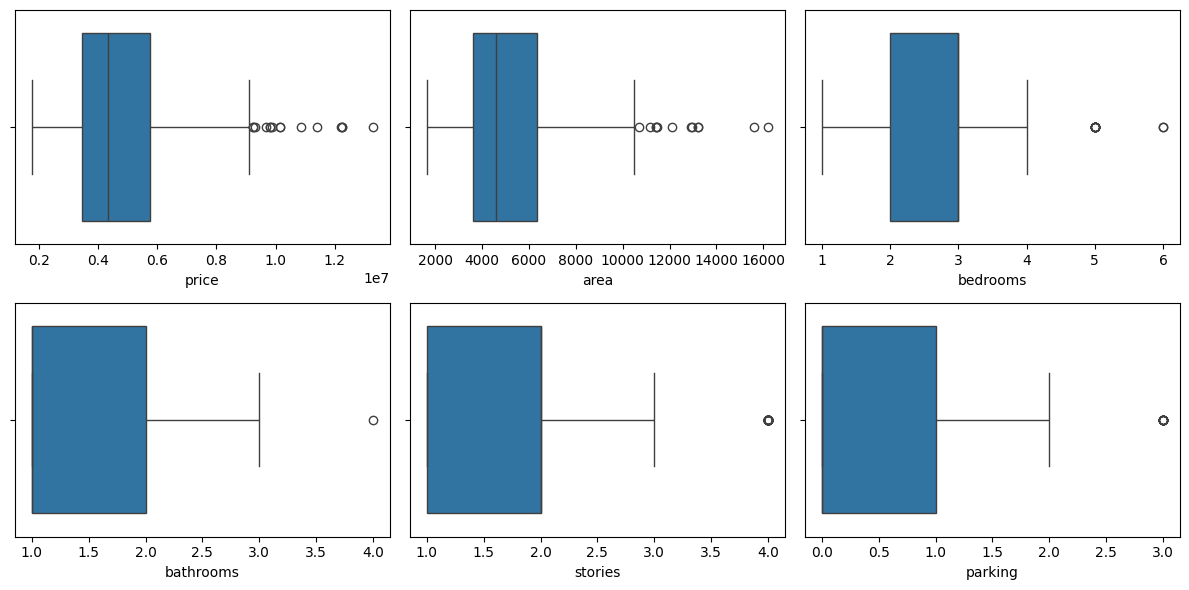

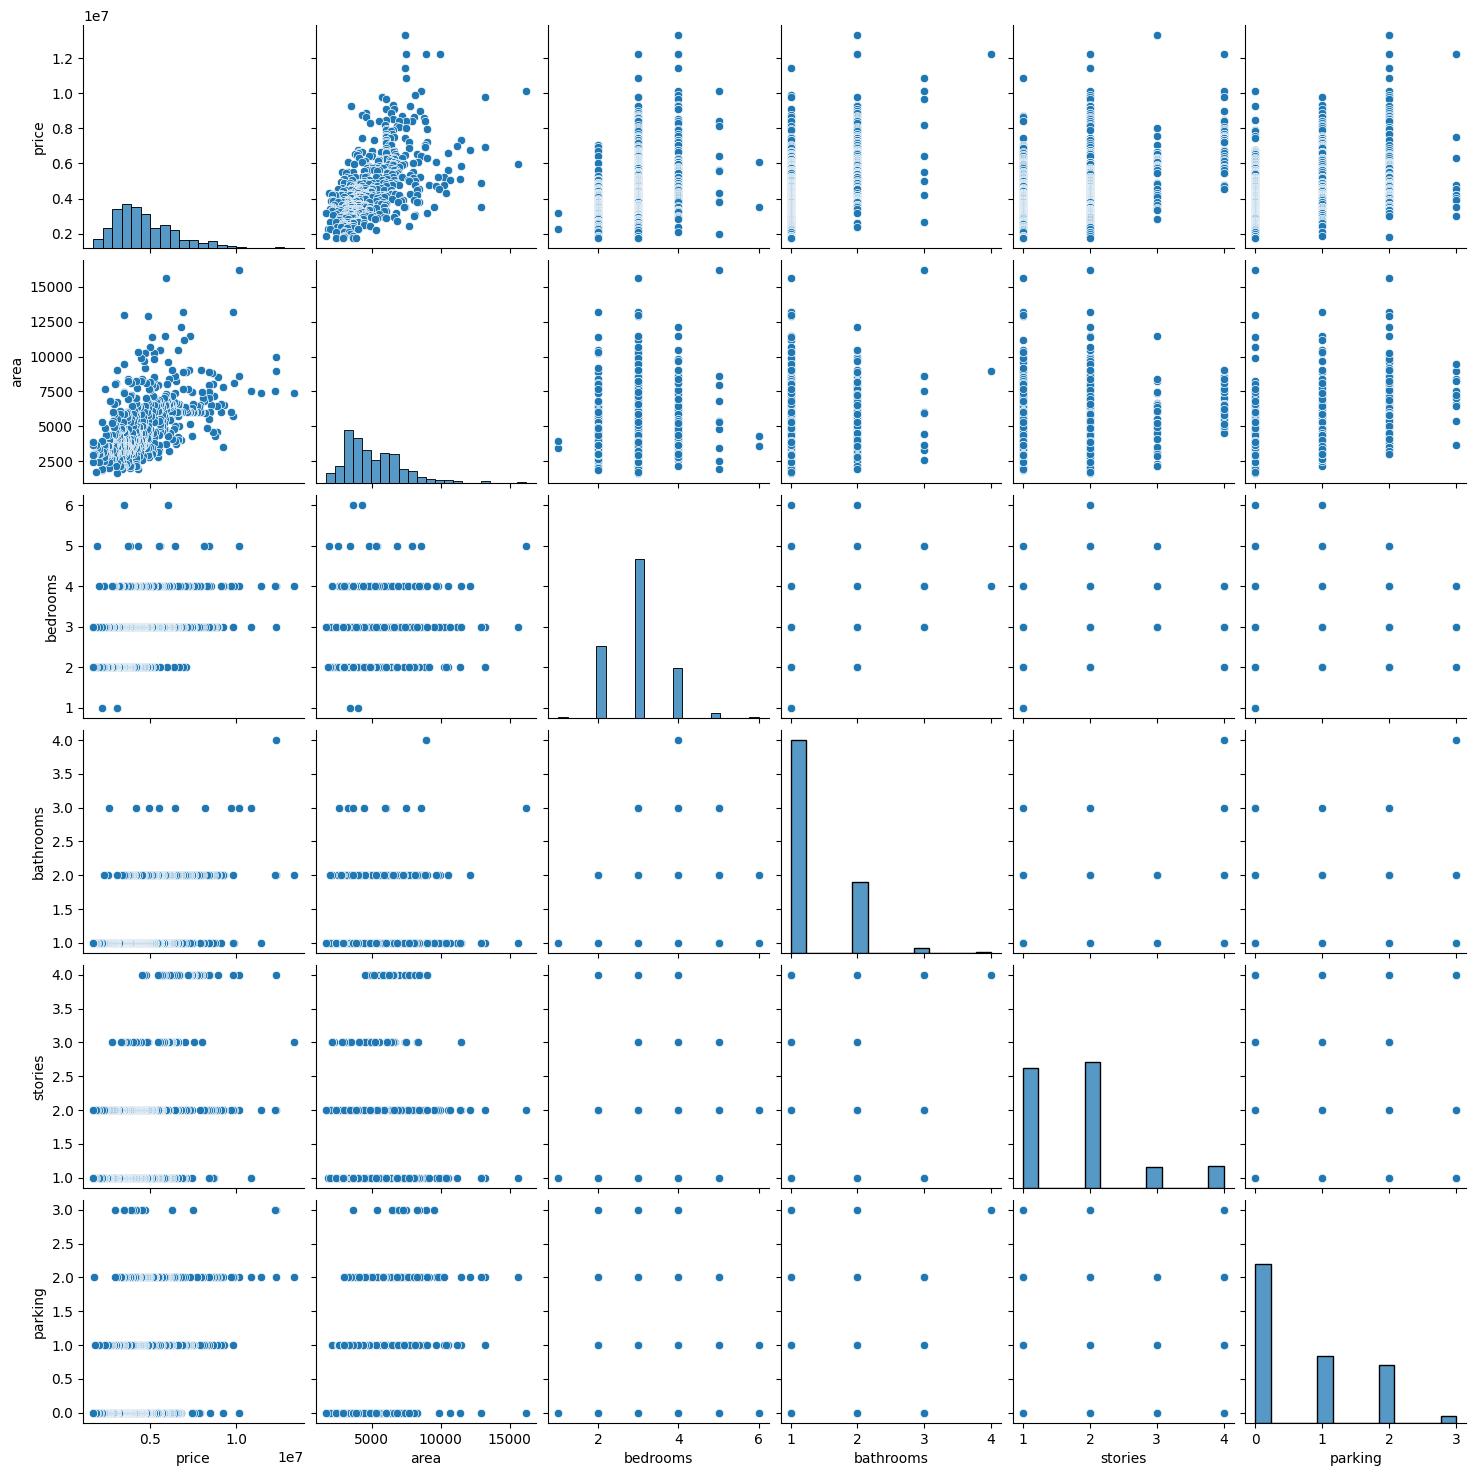


Model Performance:
Mean Squared Error: 3254189950926.7656
R-squared: 0.35618859916519896


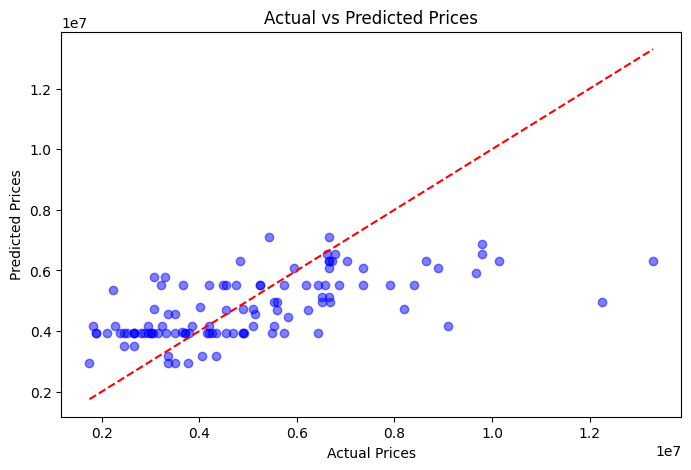

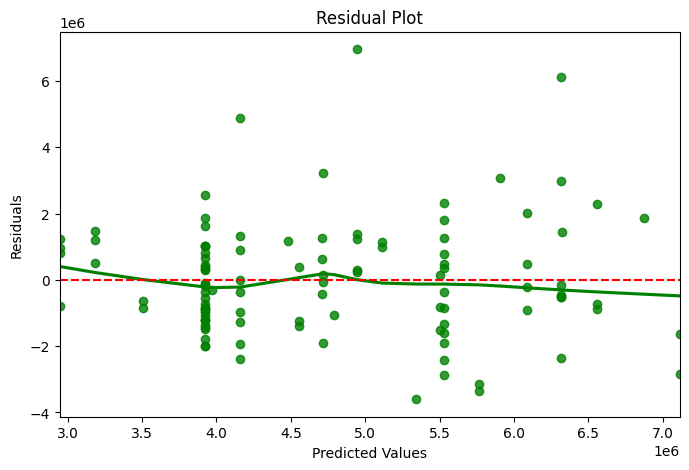

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("/content/Housing.csv")

# ==============================
# 3. Exploratory Data Analysis
# ==============================
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n", df.describe())

# ==============================
# 4. Check Missing Values
# ==============================
print("\nMissing Values:\n", df.isnull().sum())

# ==============================
# 5. Outlier Analysis
# ==============================
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

sns.boxplot(x=df['price'], ax=axs[0,0])
sns.boxplot(x=df['area'], ax=axs[0,1])
sns.boxplot(x=df['bedrooms'], ax=axs[0,2])
sns.boxplot(x=df['bathrooms'], ax=axs[1,0])
sns.boxplot(x=df['stories'], ax=axs[1,1])
sns.boxplot(x=df['parking'], ax=axs[1,2])

plt.tight_layout()
plt.show()

# ==============================
# 6. Pair Plot
# ==============================
sns.pairplot(df)
plt.show()

# ==============================
# 7. Data Preprocessing
# ==============================
features = ['mainroad', 'guestroom', 'basement',
            'hotwaterheating', 'airconditioning', 'prefarea']

df_encoded = pd.get_dummies(df[features], drop_first=True)

# Add target variable
df_encoded['price'] = df['price']

# ==============================
# 8. Train-Test Split
# ==============================
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 9. Build Model
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)

# ==============================
# 10. Prediction
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 11. Evaluation
# ==============================
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("R-squared:", r2)

# ==============================
# 12. Actual vs Predicted Plot
# ==============================
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# ==============================
# 13. Residual Plot
# ==============================
plt.figure(figsize=(8,5))
sns.residplot(x=y_pred, y=(y_test - y_pred), lowess=True, color='green')

plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Apriori algrithm Exp -6

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load Groceries dataset as a list of transactions
transactions = []
with open("/content/groceries.csv", 'r') as file:
    for line in file:
        # Strip whitespace, split by comma, and filter out empty strings
        items = [item.strip() for item in line.strip().split(',') if item.strip()]
        if items:
            transactions.append(items)

print("Dataset Loaded Successfully. First 5 transactions:")
for i in range(min(5, len(transactions))):
    print(transactions[i])

# One-hot encoding
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_data, columns=te.columns_)

# Apply Apriori
frequent_items = apriori(df_encoded, min_support=0.02, use_colnames=True)

# Generate Association Rules
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)

# Display Results
print("\nFrequent Itemsets:\n", frequent_items.head())
print("\nAssociation Rules:\n", rules[['antecedents','consequents','support','confidence','lift']].head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dataset Loaded Successfully. First 5 transactions:
['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
['tropical fruit', 'yogurt', 'coffee']
['whole milk']
['pip fruit', 'yogurt', 'cream cheese', 'meat spreads']
['other vegetables', 'whole milk', 'condensed milk', 'long life bakery product']

Frequent Itemsets:
     support        itemsets
0  0.033452      (UHT-milk)
1  0.052466          (beef)
2  0.033249       (berries)
3  0.026029     (beverages)
4  0.080529  (bottled beer)

Association Rules:
        antecedents         consequents   support  confidence      lift
0           (beef)        (whole milk)  0.021251    0.405039  1.585180
1  (bottled water)        (whole milk)  0.034367    0.310948  1.216940
2    (brown bread)        (whole milk)  0.025216    0.388715  1.521293
3         (butter)  (other vegetables)  0.020031    0.361468  1.868122
4         (butter)        (whole milk)  0.027555    0.497248  1.946053


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load Pima Indians Diabetes Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigree','Age','Outcome']
df = pd.read_csv(url, names=cols)

print(df.shape)       # (768, 9)
print(df.head())
print(df['Outcome'].value_counts())  # 0=No Diabetes, 1=Diabetes

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50        1  
1             0.351   31        0  
2             0.672   32        1  
3             0.167   21        0  
4             2.288   33        1  
Outcome
0    500
1    268
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

predictive model decison tree Exp 8


=== Decision Tree ===
Accuracy: 0.6948051948051948
              precision    recall  f1-score   support

           0       0.80      0.70      0.75        99
           1       0.56      0.69      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.72      0.69      0.70       154


=== KNN ===
Accuracy: 0.6818181818181818
              precision    recall  f1-score   support

           0       0.74      0.79      0.76        99
           1       0.56      0.49      0.52        55

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154


=== Neural Network ===
Accuracy: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.83      0.82      0.82        99
           1       0.68      0.69      0.68        55

    accuracy                       

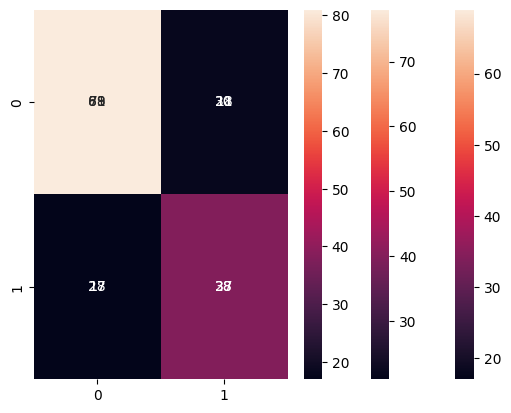

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# ==============================
# 2. Load Dataset
# ==============================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','DiabetesPedigree','Age','Outcome']

df = pd.4firead_csv(url, names=cols) https f uu

# ==============================
# 3. Split Data
# ==============================
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 4. Decision Tree
# ==============================
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')

# ==============================
# 5. KNN
# ==============================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

print("\n=== KNN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')

# ==============================
# 6. Neural Network
# ==============================
nn = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)
nn.fit(X_train_sc, y_train)
y_pred_nn = nn.predict(X_test_sc)

print("\n=== Neural Network ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt='d')

# ==============================
# 7. Final Show (single call)
# ==============================
plt.show()

temporal mining Exp 9

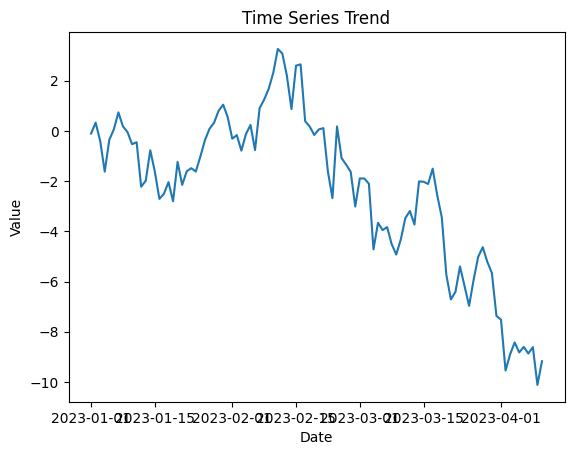

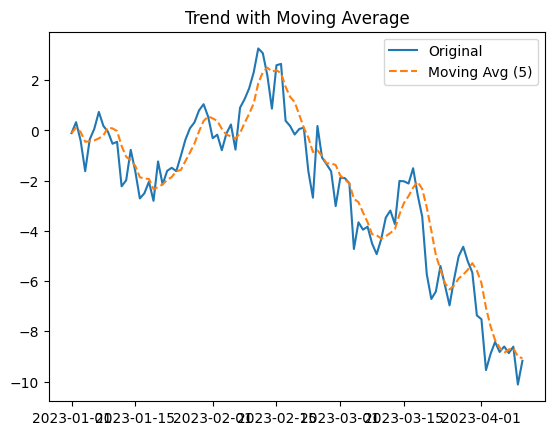

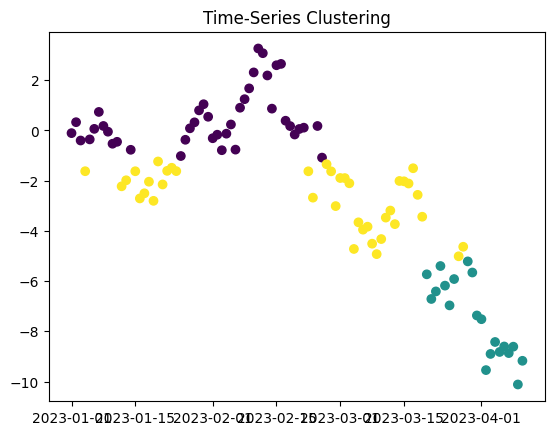

               Value  Moving_Avg  Cluster
Date                                     
2023-01-01 -0.110603   -0.110603        0
2023-01-02  0.324677    0.107037        0
2023-01-03 -0.404468   -0.063465        0
2023-01-04 -1.626976   -0.454342        2
2023-01-05 -0.360135   -0.435501        0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Create sample time-series data
dates = pd.date_range(start='2023-01-01', periods=100)
data = np.cumsum(np.random.randn(100))  # cumulative sum (trend-like)

df = pd.DataFrame({'Date': dates, 'Value': data})
df.set_index('Date', inplace=True)

# Step 2: Plot time-series (Trend Analysis)
plt.figure()
plt.plot(df.index, df['Value'])
plt.title("Time Series Trend")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# Step 3: Moving Average (Temporal Pattern)
df['Moving_Avg'] = df['Value'].rolling(window=5, min_periods=1).mean()

plt.figure()
plt.plot(df.index, df['Value'], label='Original')
plt.plot(df.index, df['Moving_Avg'], label='Moving Avg (5)', linestyle='--')
plt.legend()
plt.title("Trend with Moving Average")
plt.show()

# Step 4: Clustering time-based values
# Using only values for clustering
kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(df[['Value']])

plt.figure()
plt.scatter(df.index, df['Value'], c=df['Cluster'])
plt.title("Time-Series Clustering")
plt.show()

print(df.head())

Exp 10 - predictive anlysis micro array data

In [ ]:
# ===============================
# Microarray Predictive Analytics
# Fully Error-Proof Version
# ===============================

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# Step 1: Check if dataset exists
# ===============================

file_name = "/content/air_quality_dataset - air_quality_dataset.csv"

if not os.path.exists(file_name):
    print("Dataset not found! Creating a synthetic dataset...")

    np.random.seed(42)
    X_synthetic = np.random.rand(120, 200)   # 120 samples, 200 genes
    y_synthetic = np.random.randint(0, 2, 120)

    df_synthetic = pd.DataFrame(X_synthetic)
    df_synthetic['label'] = y_synthetic
    df_synthetic.to_csv(file_name, index=False)

    print("Synthetic dataset created as 'microarray.csv'\n")

# ===============================
# Step 2: Load dataset
# ===============================

data = pd.read_csv(file_name)

print("Dataset Loaded Successfully!")
print("Shape:", data.shape)

# ===============================
# Step 3: Clean column names
# ===============================

data.columns = data.columns.str.strip()

# ===============================
# Step 4: Separate features & label
# ===============================

# Safe approach: last column = target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# ===============================
# Step 5: Handle missing values
# ===============================

# Impute numerical columns with mean
for col in X.select_dtypes(include=np.number).columns:
    X[col] = X[col].fillna(X[col].mean())

# Impute categorical columns with mode
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna(X[col].mode()[0])

# ===============================
# Step 6: Feature scaling
# ===============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=np.number)) # Only scale numeric features

# If X contains non-numeric columns that need to be part of the final feature set,
# they should be one-hot encoded or handled appropriately before scaling or feature selection.
# For now, we'll proceed with only numeric scaled features for feature selection.

# ===============================
# Step 7: Feature selection
# ===============================

k = min(50, X_scaled.shape[1])  # avoid error if features < 50
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_scaled, y)

print("Selected Features shape:", X_selected.shape)

# ===============================
# Step 8: Train-Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# ===============================
# Step 9: Model Training
# ===============================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ===============================
# Step 10: Prediction
# ===============================

y_pred = model.predict(X_test)

# ===============================
# Step 11: Evaluation
# ===============================

print("\n===== RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Dataset Loaded Successfully!
Shape: (500, 14)
Features shape: (500, 13)
Target shape: (500,)
Selected Features shape: (500, 12)

===== RESULTS =====
Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

Biomass Burning       1.00      1.00      1.00        29
     Industrial       1.00      1.00      1.00        42
      Vehicular       1.00      1.00      1.00        29

       accuracy                           1.00       100
      macro avg       1.00      1.00      1.00       100
   weighted avg       1.00      1.00      1.00       100

Confusion Matrix:
 [[29  0  0]
 [ 0 42  0]
 [ 0  0 29]]
